In [2]:
import pandas as pd
import numpy as np
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("../data/processed/featured_marketing_data.csv")

In [4]:
spend_cols = [
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_SHOPPING_SPEND",
    "GOOGLE_PMAX_SPEND",
    "GOOGLE_DISPLAY_SPEND",
    "GOOGLE_VIDEO_SPEND",
    "META_FACEBOOK_SPEND",
    "META_INSTAGRAM_SPEND",
    "META_OTHER_SPEND",
    "TIKTOK_SPEND"
]

In [5]:
Y = df["LOG_REVENUE"]

In [6]:
def estimate_channel_effect(channel):

    T = df[channel]

    controls = [c for c in spend_cols if c != channel]

    X = df[
        controls +
        [
            "TOTAL_CLICKS",
            "TOTAL_IMPRESSIONS",
            "YEAR",
            "MONTH",
            "QUARTER",
            "DAY_OF_WEEK"
        ]
    ]

    est = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ),
        model_t=RandomForestRegressor(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ),
        n_estimators=100,
        random_state=42
    )

    est.fit(Y, T, X=X)

    effects = est.effect(X)

    return np.mean(effects), effects

In [7]:
Y = df["LOG_REVENUE"]

In [8]:
def estimate_channel_effect(channel):
    print(f"\nRunning Causal Model for: {channel}")
    T = df[channel]
    controls = [
        c for c in spend_cols
        if c != channel
    ]
    X = df[
        controls +
        [
            "TOTAL_CLICKS",
            "TOTAL_IMPRESSIONS",
            "YEAR",
            "MONTH",
            "QUARTER",
            "DAY_OF_WEEK"
        ]
    ]

    est = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ),
        model_t=RandomForestRegressor(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ),
        n_estimators=100,
        random_state=42
    )
    est.fit(
        Y,
        T,
        X=X
    )
    effects = est.effect(X)
    ate = np.mean(effects)
    print("ATE =", ate)
    return ate, effects

In [9]:
channels = [
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_SHOPPING_SPEND",
    "GOOGLE_PMAX_SPEND",
    "META_FACEBOOK_SPEND",
    "META_INSTAGRAM_SPEND",
    "TIKTOK_SPEND"
]

results = {}

for channel in channels:
    print(f"Running {channel}...")
    ate, _ = estimate_channel_effect(channel)
    results[channel] = ate

causal_results = pd.DataFrame({
    "Channel": results.keys(),
    "ATE": results.values()
})

causal_results = causal_results.sort_values(
    by="ATE",
    ascending=False
)

causal_results

Running GOOGLE_PAID_SEARCH_SPEND...

Running Causal Model for: GOOGLE_PAID_SEARCH_SPEND
ATE = 0.0006328807420209239
Running GOOGLE_SHOPPING_SPEND...

Running Causal Model for: GOOGLE_SHOPPING_SPEND
ATE = 0.0012720249729814691
Running GOOGLE_PMAX_SPEND...

Running Causal Model for: GOOGLE_PMAX_SPEND
ATE = 0.003277667870165054
Running META_FACEBOOK_SPEND...

Running Causal Model for: META_FACEBOOK_SPEND
ATE = 0.0010762389562967854
Running META_INSTAGRAM_SPEND...

Running Causal Model for: META_INSTAGRAM_SPEND
ATE = -0.054592017186986024
Running TIKTOK_SPEND...

Running Causal Model for: TIKTOK_SPEND
ATE = -0.00902132459223324


,Channel,ATE
2,GOOGLE_PMAX_SPEND,0.003278
1,GOOGLE_SHOPPING_SPEND,0.001272
3,META_FACEBOOK_SPEND,0.001076
0,GOOGLE_PAID_SEARCH_SPEND,0.000633
5,TIKTOK_SPEND,-0.009021
4,META_INSTAGRAM_SPEND,-0.054592


In [10]:
causal_results.to_csv("../results/causal_effects.csv", index=False)

In [11]:
causal_results

,Channel,ATE
2,GOOGLE_PMAX_SPEND,0.003278
1,GOOGLE_SHOPPING_SPEND,0.001272
3,META_FACEBOOK_SPEND,0.001076
0,GOOGLE_PAID_SEARCH_SPEND,0.000633
5,TIKTOK_SPEND,-0.009021
4,META_INSTAGRAM_SPEND,-0.054592


In [12]:
causal_results.to_csv(
    "../results/causal_effects.csv",
    index=False
)

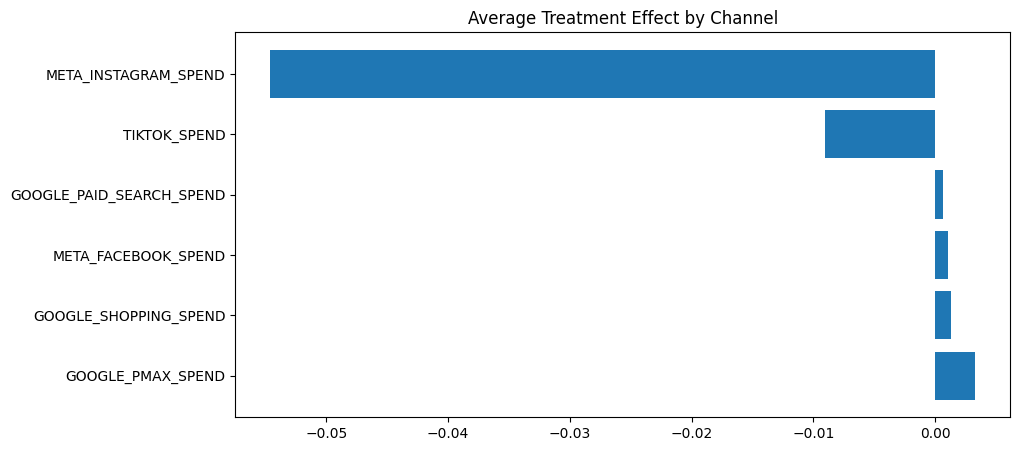

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.barh(causal_results["Channel"],causal_results["ATE"])
plt.title("Average Treatment Effect by Channel")
plt.show()